# Purpose
- Testing overfitting of mean W model as the model representing the session.
- If it's significantly higher than mean of variance explained, then we should use mean of variance explained across folds for representing the model fit
    - Also, the session model should be considered differently.
## Protocol
- Get var_explained_mean_model and mean of var_explained_fold. Scatter plot

In [137]:
from pathlib import Path
import numpy as np
import os
from matplotlib import pyplot as plt

from lamf_analysis.code_ocean import capsule_data_utils as cdu

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [138]:
def get_glm_results(session_key, version=3, data_type='events', glm_path='/root/capsule/scratch/glm'):
    if isinstance(glm_path, str):
        glm_path = Path(glm_path)
    save_dir = glm_path / f'{session_key}_glm_v{version:02}'
    glm_fn = save_dir / f'glm_results_v{version:02}_{session_key}_{data_type}.npy'
    if not os.path.exists(glm_fn):
        print(f'{session_key} not processed yet')
        return
    glm_results = np.load(glm_fn, allow_pickle=True).item()
    return glm_results

In [139]:
mouse_ids = [717824, 721291, 736963, 739564, 747107, 755252]
mouse_id = mouse_ids[4]
session_info_df = cdu.get_session_info(mouse_id)

session_key = session_info_df.iloc[1].name
glm_results = get_glm_results(session_key)

## Overfitting test per model
- Needs to be in session GLM QC

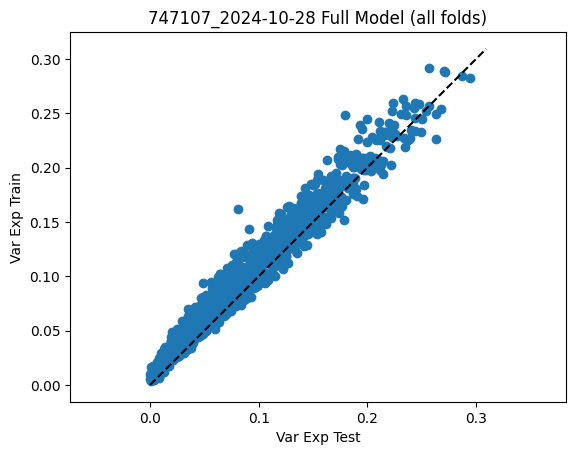

In [140]:
fig, ax = plt.subplots()
ax.scatter(glm_results['var_explained_test_cv'].sel(model='Full').values,
           glm_results['var_explained_train_cv'].sel(model='Full').values);
ax.axis('equal')
ax.set_xlabel('Var Exp Test')
ax.set_ylabel('Var Exp Train')
ax.set_title(f'{session_key} Full Model (all folds)')
max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, max_val], [0, max_val], 'k--')

Text(0.5, 0, 'Train - Test Var Explained')

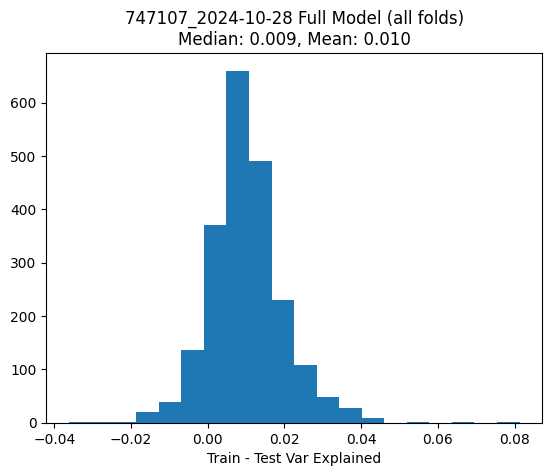

In [141]:
full_diff = glm_results['var_explained_train_cv'].sel(model='Full') - glm_results['var_explained_test_cv'].sel(model='Full')
fig, ax = plt.subplots()
ax.hist(full_diff.values.flatten(), bins=20);
ax.set_title(f'{session_key} Full Model (all folds)\nMedian: {np.median(full_diff.values):.3f}, Mean: {np.mean(full_diff.values):.3f}')
ax.set_xlabel('Train - Test Var Explained')

Text(0.5, 0, 'Test Var Explained')

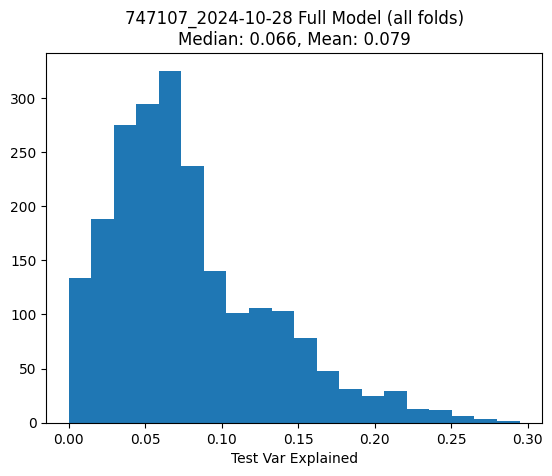

In [142]:
test_full = glm_results['var_explained_test_cv'].sel(model='Full')
fig, ax = plt.subplots()
ax.hist(test_full.values.flatten(), bins=20);
ax.set_title(f'{session_key} Full Model (all folds)\nMedian: \
{np.median(test_full.values):.3f}, \
Mean: {np.mean(test_full.values):.3f}')
ax.set_xlabel('Test Var Explained')

## Mean model vs mean of VE

In [143]:
ve_mean_model = glm_results['var_explained_mean_model'].sel(model='Full')
mean_of_ve = glm_results['var_explained_test_cv'].sel(model='Full').mean(dim='test_fold_ind')

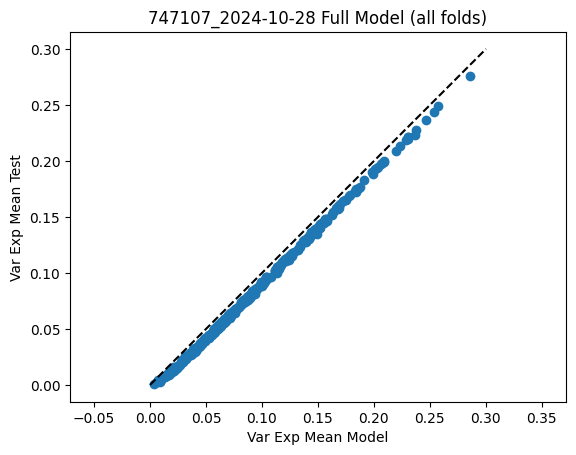

In [144]:
fig, ax = plt.subplots()
ax.scatter(ve_mean_model.values, mean_of_ve.values)
ax.axis('equal')
ax.set_xlabel('Var Exp Mean Model')
ax.set_ylabel('Var Exp Mean Test')
ax.set_title(f'{session_key} Full Model (all folds)')
max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, max_val], [0, max_val], 'k--')

# Make these as session GLM QC plots